In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/olist_project/master_table.csv')
print(f"Loaded: {df.shape}")

Mounted at /content/drive
Loaded: (110840, 36)


Part A — RFM Customer Segmentation

— Build RFM table

RFM = Recency (how recently they bought), Frequency (how often), Monetary (how much they spent). Standard DA/DS technique.

In [2]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

print(rfm.describe())
print(rfm.head())

            Recency     Frequency       Monetary
count  93358.000000  93358.000000   93358.000000
mean     237.941773      1.033420     212.964557
std      152.591453      0.209097     646.223866
min        1.000000      1.000000       0.000000
25%      114.000000      1.000000      63.830000
50%      219.000000      1.000000     113.140000
75%      346.000000      1.000000     202.637500
max      714.000000     15.000000  109312.640000
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89


 KMeans clustering (4 segments)

In [3]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

segment_map = {
    rfm.groupby('Segment')['Monetary'].mean().idxmax(): 'Champions',
    rfm.groupby('Segment')['Recency'].mean().idxmin(): 'Loyal Customers',
    rfm.groupby('Segment')['Recency'].mean().idxmax(): 'At Risk',
    rfm.groupby('Segment')['Frequency'].mean().idxmin(): 'Lost Customers'
}
rfm['Segment_Name'] = rfm['Segment'].map(segment_map).fillna('Potential')

print(rfm['Segment_Name'].value_counts())
print(rfm.groupby('Segment_Name')[['Recency','Frequency','Monetary']].mean().round(2))

Segment_Name
Loyal Customers    51959
Lost Customers     38580
Potential           2797
Champions             22
Name: count, dtype: int64
                 Recency  Frequency  Monetary
Segment_Name                                 
Champions         214.23       1.27  26932.41
Lost Customers    387.28       1.00    199.35
Loyal Customers   128.01       1.00    198.76
Potential         220.34       2.11    454.36


Visualize segments

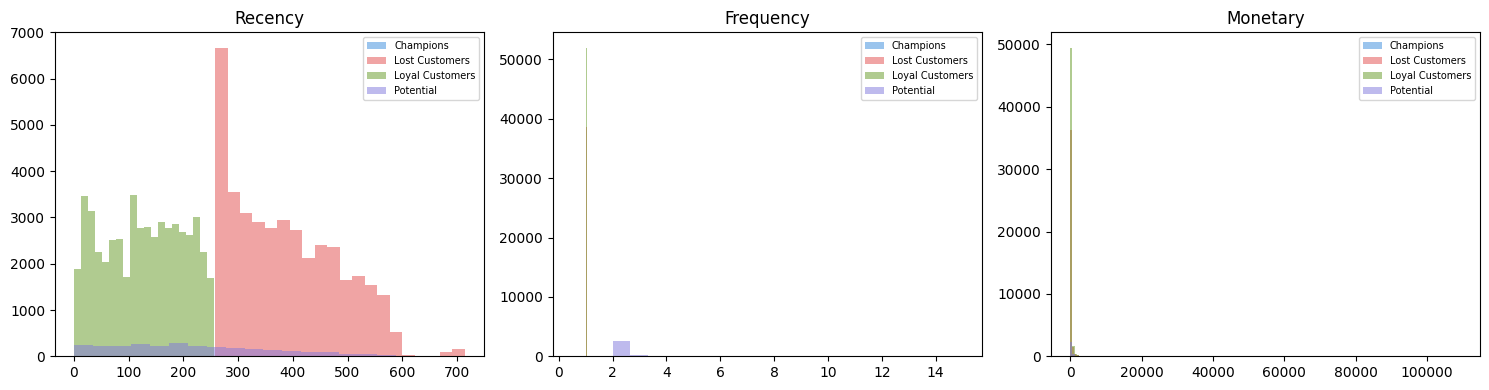

Chart saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
colors = {'Champions':'#378ADD','Loyal Customers':'#639922','At Risk':'#BA7517','Lost Customers':'#E24B4A','Potential':'#7F77DD'}

for i, col in enumerate(['Recency','Frequency','Monetary']):
    for seg, grp in rfm.groupby('Segment_Name'):
        axes[i].hist(grp[col], alpha=0.5, label=seg, color=colors.get(seg,'gray'), bins=20)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/olist_project/rfm_segments.png', dpi=150)
plt.show()
print("Chart saved!")

Part B — Delivery Delay Prediction

 — Prepare features

In [5]:
features = df[[
    'payment_value', 'review_score',
    'seller_state', 'customer_state',
    'product_category_name_english',
    'is_late'
]].dropna()

features = pd.get_dummies(features, columns=['seller_state','customer_state','product_category_name_english'])

X = features.drop('is_late', axis=1)
y = features['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Late delivery rate: {y.mean()*100:.1f}%")

Train: (88669, 123), Test: (22168, 123)
Late delivery rate: 6.6%


Train + evaluate model

In [6]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("=== Model Performance ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

=== Model Performance ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     20717
           1       0.60      0.04      0.08      1451

    accuracy                           0.94     22168
   macro avg       0.77      0.52      0.52     22168
weighted avg       0.92      0.94      0.91     22168

ROC-AUC Score: 0.828


 Business impact statement

This is what makes your project stand out — translate model results into money.

In [7]:
late_orders = df['is_late'].sum()
avg_order_value = df['payment_value'].mean()
assumed_refund_rate = 0.15

estimated_loss = late_orders * avg_order_value * assumed_refund_rate

print("=== Business Impact ===")
print(f"Total late deliveries: {late_orders:,}")
print(f"Avg order value: R${avg_order_value:.2f}")
print(f"Estimated refund exposure: R${estimated_loss:,.2f}")
print(f"\nIf model catches 80% of late orders proactively:")
print(f"Potential savings: R${estimated_loss * 0.80:,.2f}")

=== Business Impact ===
Total late deliveries: 7,293
Avg order value: R$179.38
Estimated refund exposure: R$196,232.79

If model catches 80% of late orders proactively:
Potential savings: R$156,986.23


Save outputs

In [8]:
import joblib
PATH = '/content/drive/MyDrive/olist_project/'

rfm.to_csv(PATH + 'rfm_segments.csv', index=False)
joblib.dump(model, PATH + 'delay_model.pkl')
joblib.dump(X_train.columns.tolist(), PATH + 'model_features.pkl')

print("RFM CSV, model .pkl and features saved to Drive!")

RFM CSV, model .pkl and features saved to Drive!
